# Active Preference Learning via Polytope Volume Removal

Instead of heuristic sample filtering, we maintain the feasible set $\Omega_t$ as an **explicit polytope** $\{\omega : A\omega \leq b\}$.

Each pairwise response (left, right, indifferent, incomparable) adds **linear constraints** on $\omega$,
and we select queries to **maximize expected volume removal** (Sadigh et al. 2017).

### Constraint rules (from the frame model)

Given query gaps $\Delta_j$ and thresholds $\tau, \tau'$:

| Response | Constraints on $\omega$ |
|----------|------------------------|
| **Left** ($Y \succ Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) \geq 0$ |
| **Right** ($Y \prec Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) \leq 0$ |
| **Indifferent** ($Y \sim Y'$) | $\sum \omega_j |\Delta_j| \leq \tau - \eta$ |
| **Incomparable** ($Y \bowtie Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$, $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) < 0$, $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) > 0$ |

In [135]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.spatial.distance import pdist
from typing import List, Tuple, Optional, Set
import matplotlib.pyplot as plt
import seaborn as sns

from core import (
    Patient, PairwiseQuery, FEATURE_NAMES, FEATURE_RANGES,
    compute_frame_gaps, predict_response, compute_aggregate_scores,
    generate_random_patient,
)
# Algorithm parameters
TAU = 0  # Intensity threshold
TAU_PRIME = 0  # Resolvability threshold
LAMBDA_X = 1.0  # Query scaling factor (can be a function later)
sns.set_style('whitegrid')

print(f'Features: {FEATURE_NAMES}')
print(f'tau={TAU}, tau_prime={TAU_PRIME}, lambda_x={LAMBDA_X}')

Features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
tau=0, tau_prime=0, lambda_x=1.0


## Polytope class

H-representation: $\Omega = \{\omega \in \mathbb{R}^d : A\omega \leq b\}$

With hit-and-run MCMC sampling and Chebyshev center computation.

In [126]:
class ConstraintPolytope:
    """Convex polytope in H-representation: {w : Aw <= b}.

    For the simplex, we store the equality sum(w)=1 separately and
    handle it via two inequality constraints (sum <= 1, -sum <= -1).
    The Chebyshev center LP uses a tolerance approach to find a
    strictly interior point of the inequality system.
    """

    def __init__(self, dim: int, geometry: str = 'simplex'):
        self.dim = dim
        self.geometry = geometry
        self._A_rows = []
        self._b_vals = []
        self._center_cache = None
        self._use_sphere_constraint = False

        if geometry == 'simplex':
            # w_j >= 0  =>  -w_j <= 0
            for j in range(dim):
                row = np.zeros(dim)
                row[j] = -1.0
                self._A_rows.append(row)
                self._b_vals.append(0.0)
            # sum w_j <= 1
            self._A_rows.append(np.ones(dim))
            self._b_vals.append(1.0)
            # sum w_j >= 1  =>  -sum w_j <= -1
            self._A_rows.append(-np.ones(dim))
            self._b_vals.append(-1.0)

        elif geometry == 'sphere':
            for j in range(dim):
                row_pos = np.zeros(dim)
                row_pos[j] = 1.0
                self._A_rows.append(row_pos)
                self._b_vals.append(1.0)
                row_neg = np.zeros(dim)
                row_neg[j] = -1.0
                self._A_rows.append(row_neg)
                self._b_vals.append(1.0)
            self._use_sphere_constraint = True
        else:
            raise ValueError(f'Unknown geometry: {geometry}')

    @property
    def A(self) -> np.ndarray:
        return np.array(self._A_rows)

    @property
    def b(self) -> np.ndarray:
        return np.array(self._b_vals)

    @property
    def n_constraints(self) -> int:
        return len(self._A_rows)

    def add_constraint(self, a: np.ndarray, b_val: float):
        """Add constraint a^T w <= b_val."""
        self._A_rows.append(a.copy())
        self._b_vals.append(b_val)
        self._center_cache = None

    def is_feasible(self, w: np.ndarray, tol: float = 1e-8) -> bool:
        """Check if w satisfies all constraints."""
        violations = self.A @ w - self.b
        if np.any(violations > tol):
            return False
        if self._use_sphere_constraint and np.linalg.norm(w) > 1.0 + tol:
            return False
        return True

    def chebyshev_center(self) -> Optional[np.ndarray]:
        """Find a strictly interior point of the polytope.

        For polytopes with equality constraints (like the simplex where
        sum=1), the classical Chebyshev center has radius 0. Instead we
        find the point that maximizes the minimum slack across all
        INEQUALITY constraints (excluding exact equalities).

        We detect near-equalities (pairs a^T x <= b and -a^T x <= -b)
        and handle them as equality constraints in the LP.
        """
        if self._center_cache is not None:
            return self._center_cache.copy()

        A = self.A
        b_vec = self.b
        m, d = A.shape

        # Detect equality pairs: rows i,j where A[i] ≈ -A[j] and b[i] ≈ -b[j]
        eq_rows = set()
        ineq_rows = list(range(m))
        for i in range(m):
            for j in range(i + 1, m):
                if (np.allclose(A[i], -A[j], atol=1e-10) and
                        abs(b_vec[i] + b_vec[j]) < 1e-10):
                    eq_rows.add(i)
                    eq_rows.add(j)

        ineq_rows = [i for i in range(m) if i not in eq_rows]
        eq_row_list = sorted(eq_rows)

        if len(ineq_rows) == 0:
            # Only equalities — just solve for feasibility
            # Use one row from each equality pair
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(A[i])
                    b_eq_vals.append(b_vec[i])
            A_eq = np.array(A_eq_rows)
            b_eq = np.array(b_eq_vals)
            # Least-norm solution
            x, _, _, _ = np.linalg.lstsq(A_eq, b_eq, rcond=None)
            if self.is_feasible(x):
                self._center_cache = x
                return x.copy()
            return None

        # Build LP: max r s.t. a_i^T x + r ||a_i|| <= b_i (for ineq rows)
        #           a_j^T x = b_j (for equality rows)
        A_ineq = A[ineq_rows]
        b_ineq = b_vec[ineq_rows]

        norms = np.linalg.norm(A_ineq, axis=1, keepdims=True)
        # Avoid division issues for zero-norm rows
        norms = np.maximum(norms, 1e-15)

        # Variables: [x_1, ..., x_d, r]
        c_obj = np.zeros(d + 1)
        c_obj[-1] = -1.0  # maximize r

        A_lp = np.hstack([A_ineq, norms])
        b_lp = b_ineq

        # Equality constraints from detected pairs (keep one per pair)
        A_eq_lp = None
        b_eq_lp = None
        if len(eq_row_list) > 0:
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(np.append(A[i], 0.0))  # r doesn't appear
                    b_eq_vals.append(b_vec[i])
            if A_eq_rows:
                A_eq_lp = np.array(A_eq_rows)
                b_eq_lp = np.array(b_eq_vals)

        bounds = [(None, None)] * d + [(0, None)]

        result = linprog(c_obj, A_ub=A_lp, b_ub=b_lp,
                         A_eq=A_eq_lp, b_eq=b_eq_lp,
                         bounds=bounds, method='highs')

        if result.success:
            center = result.x[:d]
            if self.is_feasible(center):
                self._center_cache = center
                return center.copy()

        # Fallback: try the centroid (1/d, ..., 1/d) for simplex
        if self.geometry == 'simplex':
            centroid = np.ones(d) / d
            if self.is_feasible(centroid):
                self._center_cache = centroid
                return centroid.copy()

        return None

    def _hit_and_run_step(self, x: np.ndarray) -> np.ndarray:
        """One hit-and-run step: random direction, find chord, sample uniformly."""
        A = self.A
        b_vec = self.b

        direction = np.random.randn(self.dim)
        direction /= np.linalg.norm(direction)

        # For simplex: project direction onto the sum=1 hyperplane
        if self.geometry == 'simplex':
            direction -= direction.mean()
            norm = np.linalg.norm(direction)
            if norm < 1e-15:
                return x
            direction /= norm

        # Find t range: A(x + t*d) <= b  =>  t*(Ad) <= b - Ax
        Ad = A @ direction
        residuals = b_vec - A @ x

        t_min = -np.inf
        t_max = np.inf

        for i in range(len(Ad)):
            if Ad[i] > 1e-12:
                t_max = min(t_max, residuals[i] / Ad[i])
            elif Ad[i] < -1e-12:
                t_min = max(t_min, residuals[i] / Ad[i])

        if t_min >= t_max - 1e-15:
            return x

        # For sphere constraint, also clip t range
        if self._use_sphere_constraint:
            a_coef = np.dot(direction, direction)
            b_coef = 2 * np.dot(x, direction)
            c_coef = np.dot(x, x) - 1.0
            disc = b_coef**2 - 4 * a_coef * c_coef
            if disc > 0:
                sqrt_disc = np.sqrt(disc)
                t_lo = (-b_coef - sqrt_disc) / (2 * a_coef)
                t_hi = (-b_coef + sqrt_disc) / (2 * a_coef)
                t_min = max(t_min, t_lo)
                t_max = min(t_max, t_hi)
            else:
                return x

        if t_min >= t_max - 1e-15:
            return x

        t = np.random.uniform(t_min, t_max)
        return x + t * direction

    def sample(self, n_samples: int, burn_in: int = 500, thin: int = 10) -> np.ndarray:
        """Sample from the polytope using hit-and-run MCMC."""
        center = self.chebyshev_center()
        if center is None:
            raise ValueError('Polytope appears empty (no Chebyshev center found)')

        x = center.copy()
        samples = []

        total_steps = burn_in + n_samples * thin
        for step in range(total_steps):
            x = self._hit_and_run_step(x)
            if step >= burn_in and (step - burn_in) % thin == 0:
                samples.append(x.copy())

        return np.array(samples)


# Quick test
poly = ConstraintPolytope(5, geometry='simplex')
center = poly.chebyshev_center()
print(f'Simplex Chebyshev center: {center}')
print(f'Sum = {center.sum():.4f}, all >= 0: {np.all(center >= -1e-10)}')
print(f'Initial constraints: {poly.n_constraints}')

samples = poly.sample(500, burn_in=200, thin=5)
print(f'\nSampled {len(samples)} points from simplex')
print(f'  Sum range: [{samples.sum(axis=1).min():.6f}, {samples.sum(axis=1).max():.6f}]')
print(f'  Min weight: {samples.min():.4f}')
print(f'  Mean: {samples.mean(axis=0)}')

Simplex Chebyshev center: [0.2 0.2 0.2 0.2 0.2]
Sum = 1.0000, all >= 0: True
Initial constraints: 7

Sampled 500 points from simplex
  Sum range: [1.000000, 1.000000]
  Min weight: 0.0000
  Mean: [0.22137947 0.2113875  0.16965335 0.19443367 0.203146  ]


In [127]:
# Also test sphere geometry
poly_sphere = ConstraintPolytope(5, geometry='sphere')
center_s = poly_sphere.chebyshev_center()
print(f'Sphere Chebyshev center: {center_s}')
print(f'||center|| = {np.linalg.norm(center_s):.4f}')

samples_s = poly_sphere.sample(500, burn_in=200, thin=5)
norms = np.linalg.norm(samples_s, axis=1)
print(f'\nSampled {len(samples_s)} points from unit ball')
print(f'  ||w|| range: [{norms.min():.4f}, {norms.max():.4f}]')
print(f'  Mean: {samples_s.mean(axis=0)}')

Sphere Chebyshev center: [-0. -0. -0. -0. -0.]
||center|| = 0.0000

Sampled 500 points from unit ball
  ||w|| range: [0.2054, 0.9994]
  Mean: [ 0.02858729 -0.02047414 -0.01794577 -0.01784328 -0.02999844]


## Constraint generation from responses

Convert each (query, response) pair into linear constraints $a^\top \omega \leq b$.

In [128]:
def response_to_constraints(
    query: PairwiseQuery,
    response: str,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
) -> List[Tuple[np.ndarray, float]]:
    """
    Convert a (query, response) into linear constraints on omega.

    Returns list of (a, b) where each represents: a^T omega <= b.

    Only active frames (|Δ_j| >= tau) participate.

    For strict inequalities (incomparable, indifferent), we use the
    non-strict form (<=, >=) since the boundary has measure zero and
    doesn't affect volume. This avoids the need for an eta parameter
    that could accidentally exclude the true weights.

    Left:          r >= tau  AND  Delta >= tau' * r
    Right:         r >= tau  AND  Delta <= -tau' * r
    Indifferent:   r <= tau  (non-strict relaxation of r < tau)
    Incomparable:  r >= tau  AND  Delta <= tau' * r  AND  Delta >= -tau' * r
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    abs_gaps = np.abs(gaps)

    # Zero out inactive frames
    mask = np.zeros(len(gaps))
    for j in active_frames:
        mask[j] = 1.0
    gaps_active = gaps * mask
    abs_gaps_active = abs_gaps * mask

    constraints = []

    if response == 'left':
        # r >= tau  =>  -|Δ|^T ω <= -tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta >= tau' * r  =>  -(Δ - τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active - tau_prime * abs_gaps_active), 0.0))

    elif response == 'right':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= -tau' * r  =>  (Δ + τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active + tau_prime * abs_gaps_active, 0.0))

    elif response == 'indifferent':
        # r <= tau  (non-strict: boundary has measure zero)
        constraints.append((abs_gaps_active, tau))

    elif response == 'incomparable':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= tau' * r  (non-strict)  =>  (Δ - τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active - tau_prime * abs_gaps_active, 0.0))
        # Delta >= -tau' * r  (non-strict)  =>  -(Δ + τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active + tau_prime * abs_gaps_active), 0.0))

    else:
        raise ValueError(f'Unknown response: {response}')

    return constraints


def classify_samples_active(
    samples: np.ndarray,
    query: PairwiseQuery,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
) -> np.ndarray:
    """
    Classify each sample using active-frame logic (matching predict_response).
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)

    if len(active_frames) == 0:
        return np.full(len(samples), 'indifferent', dtype=object)

    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    abs_active_gaps = np.abs(active_gaps)
    active_weights = samples[:, active_list]

    r_vals = active_weights @ abs_active_gaps
    delta_vals = active_weights @ active_gaps

    N = len(samples)
    responses = np.empty(N, dtype=object)

    intense = r_vals >= tau
    responses[~intense] = 'indifferent'

    strongly_left = intense & (delta_vals >= tau_prime * r_vals)
    strongly_right = intense & (delta_vals <= -tau_prime * r_vals)
    incomparable = intense & ~strongly_left & ~strongly_right

    responses[strongly_left] = 'left'
    responses[strongly_right] = 'right'
    responses[incomparable] = 'incomparable'

    return responses


# Verify: oracle weights must satisfy constraints they generate
oracle_w_test = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

test_left = Patient(0.6, 0.8, 0.2, 0.5, 0.4)
test_right = Patient(0.2, 0.2, 0.6, 0.3, 0.8)
test_query = PairwiseQuery(test_left, test_right)

resp = predict_response(test_query, oracle_w_test)
gaps_t, active_t = compute_frame_gaps(test_query, LAMBDA_X, TAU)
print(f'Test gaps: {gaps_t}')
print(f'Active frames (|gap| >= {TAU}): {sorted(active_t)}')
print(f'Oracle response: {resp}')

cs = response_to_constraints(test_query, resp)
print(f'\nConstraints ({len(cs)}):')
all_satisfied = True
for a, bv in cs:
    val = np.dot(a, oracle_w_test)
    ok = val <= bv + 1e-10
    all_satisfied &= ok
    print(f'  a^T w = {val:.6f} <= {bv:.6f}  {"OK" if ok else "VIOLATED!"}')
print(f'\nOracle satisfies all constraints: {all_satisfied}')

Test gaps: [ 0.4  0.6 -0.4  0.2 -0.4]
Active frames (|gap| >= 0): [0, 1, 2, 3, 4]
Oracle response: indifferent

Constraints (1):
  a^T w = 0.480000 <= 0.000000  VIOLATED!

Oracle satisfies all constraints: False


## Volume removal query selection

Given samples from $\Omega_t$, select the query whose response will remove the most volume.

For each candidate query, classify every sample by which response it would produce,
then pick the query with the most balanced split (maximizes minimum volume removed).

In [129]:
def select_query_volume_removal(
    candidates: List[PairwiseQuery],
    samples: np.ndarray,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
) -> Tuple[PairwiseQuery, dict]:
    """
    Select query that maximizes the minimum volume removed across all
    possible responses (Sadigh et al. criterion).

    Uses active-frame classification to match the oracle.
    """
    N = len(samples)
    best_query = None
    best_score = -1.0
    best_info = {}

    for query in candidates:
        responses = classify_samples_active(samples, query, tau, tau_prime, lambda_x)

        counts = {}
        for r in ['left', 'right', 'indifferent', 'incomparable']:
            counts[r] = np.sum(responses == r)

        active_fracs = [c / N for c in counts.values() if c > 0]
        if len(active_fracs) == 0:
            continue

        max_surviving = max(active_fracs)
        min_volume_removed = 1.0 - max_surviving

        if min_volume_removed > best_score:
            best_score = min_volume_removed
            best_query = query
            best_info = {
                'min_volume_removed': min_volume_removed,
                'counts': counts.copy(),
                'max_surviving_frac': max_surviving,
            }

    if best_query is None:
        best_query = candidates[0]
        best_info = {'min_volume_removed': 0.0}

    return best_query, best_info


print('Volume removal query selection defined.')

Volume removal query selection defined.


## Active learning loop

In [130]:
from scipy.stats import norm as normal_dist
from typing import Callable


def predict_thurstone(query, weights, sigma=1.0, threshold=0.5):
    """Thurstone-Mosteller (Case V): P(left) = Phi(w . delta_x / sigma)."""
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    z = np.dot(weights, delta_x) / sigma
    prob_left = normal_dist.cdf(z)
    if prob_left > threshold:
        return 'left'
    elif prob_left < 1.0 - threshold:
        return 'right'
    else:
        return 'indifferent'


def predict_bt(query, weights, threshold=0.5):
    """Bradley-Terry: P(left) = sigmoid(w . delta_x)."""
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    logit = np.dot(weights, delta_x)
    prob_left = 1.0 / (1.0 + np.exp(-logit))
    if prob_left > threshold:
        return 'left'
    elif prob_left < 1.0 - threshold:
        return 'right'
    else:
        return 'indifferent'


def predict_frame(query, weights, tau=TAU, tau_prime=TAU_PRIME, lambda_x=LAMBDA_X):
    """Frame model (wrapper matching the oracle_model signature)."""
    return predict_response(query, weights, tau=tau, lambda_x=lambda_x, tau_prime=tau_prime)


def generate_candidate_queries_normalized(
    n_candidates: int = 50,
) -> List[PairwiseQuery]:
    """Generate candidate queries with features normalized to [0,1]."""
    candidates = []
    for _ in range(n_candidates):
        left = Patient(
            elderlyDep=np.random.uniform(0, 1),
            lifeYearsGained=np.random.uniform(0, 1),
            obesity=np.random.uniform(0, 1),
            weeklyWorkhours=np.random.uniform(0, 1),
            yearsWaiting=np.random.uniform(0, 1),
        )
        right = Patient(
            elderlyDep=np.random.uniform(0, 1),
            lifeYearsGained=np.random.uniform(0, 1),
            obesity=np.random.uniform(0, 1),
            weeklyWorkhours=np.random.uniform(0, 1),
            yearsWaiting=np.random.uniform(0, 1),
        )
        candidates.append(PairwiseQuery(left, right))
    return candidates


def active_learning_polytope(
    max_iterations: int = 100,
    n_samples: int = 1000,
    n_candidates: int = 100,
    geometry: str = 'simplex',
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    oracle_weights: Optional[np.ndarray] = None,
    oracle_model: Callable = None,
    target_diameter: float = 0.1,
    verbose: bool = True,
) -> Tuple[ConstraintPolytope, List[dict]]:
    """
    Active learning via polytope volume removal.

    Parameters
    ----------
    oracle_model : callable(query, weights) -> str
        Any function that takes a PairwiseQuery and weight vector and
        returns one of 'left', 'right', 'indifferent', 'incomparable'.
        Defaults to the frame model (predict_response).
    """
    dim = len(FEATURE_NAMES)
    polytope = ConstraintPolytope(dim, geometry=geometry)
    history = []

    if oracle_weights is None:
        oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
    if oracle_model is None:
        oracle_model = lambda q, w: predict_response(q, w, tau=tau, lambda_x=lambda_x, tau_prime=tau_prime)

    model_name = getattr(oracle_model, '__name__', str(oracle_model))

    if verbose:
        print(f'Polytope Active Learning ({geometry}, oracle={model_name})')
        print(f'=' * 60)
        print(f'Oracle weights: {dict(zip(FEATURE_NAMES, oracle_weights))}')
        print(f'Target diameter: {target_diameter}')
        print(f'Max iterations: {max_iterations}')
        print()

    for iteration in range(max_iterations):
        # Sample from current polytope
        try:
            samples = polytope.sample(n_samples, burn_in=300, thin=5)
        except ValueError as e:
            if verbose:
                print(f'  Polytope empty! {e}')
            break

        # Compute diameter
        if len(samples) > 1:
            if len(samples) > 200:
                idx = np.random.choice(len(samples), 200, replace=False)
                sub = samples[idx]
            else:
                sub = samples
            diam = pdist(sub, metric='cityblock').max()
        else:
            diam = 0.0

        mean_w = samples.mean(axis=0)

        if verbose:
            print(f'Iteration {iteration + 1}')
            print(f'  Constraints: {polytope.n_constraints}')
            print(f'  L1 diameter: {diam:.4f}')
            print(f'  Mean w: {np.array2string(mean_w, precision=3)}')

        if diam <= target_diameter:
            if verbose:
                print(f'\n  Converged! Diameter {diam:.4f} <= {target_diameter}')
            history.append({
                'iteration': iteration + 1,
                'diameter': diam,
                'n_constraints': polytope.n_constraints,
                'mean_weights': mean_w.copy(),
            })
            break

        # Generate candidates and select query
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, query_info = select_query_volume_removal(
            candidates, samples, tau, tau_prime, lambda_x
        )

        if verbose:
            print(f'  Volume removal: {query_info.get("min_volume_removed", 0):.3f}')
            print(f'  Split: {query_info.get("counts", {})}')

        # Oracle response via pluggable model
        response = oracle_model(query, oracle_weights)

        if verbose:
            print(f'  Oracle response: {response}')

        # Add constraints (active-frame masked, non-strict)
        new_constraints = response_to_constraints(
            query, response, tau, tau_prime, lambda_x
        )
        for a, bv in new_constraints:
            polytope.add_constraint(a, bv)

        # Verify polytope still feasible
        center = polytope.chebyshev_center()
        if center is None:
            if verbose:
                print(f'  WARNING: Polytope became empty!')
            break

        # Cosine similarity to ground truth
        cos_sim = np.dot(mean_w, oracle_weights) / (
            np.linalg.norm(mean_w) * np.linalg.norm(oracle_weights) + 1e-10
        )

        history.append({
            'iteration': iteration + 1,
            'query': query,
            'response': response,
            'diameter': diam,
            'n_constraints': polytope.n_constraints,
            'mean_weights': mean_w.copy(),
            'cosine_similarity': cos_sim,
            'volume_removed': query_info.get('min_volume_removed', 0),
        })

        if verbose:
            print(f'  Cosine similarity to oracle: {cos_sim:.4f}')
            print()

    # Final summary
    try:
        final_samples = polytope.sample(n_samples, burn_in=300, thin=5)
        learned = final_samples.mean(axis=0)
        if verbose:
            print(f'\nLearned weights:')
            for fn, lw, ow in zip(FEATURE_NAMES, learned, oracle_weights):
                print(f'  {fn:20s}: {lw:.4f}  (oracle: {ow:.4f})')
            l1_err = np.abs(learned - oracle_weights).sum()
            print(f'\nL1 error: {l1_err:.4f}')
    except ValueError:
        if verbose:
            print('\nCould not sample from final polytope.')

    return polytope, history


print('Active learning loop defined.')
print('Available oracle models: predict_frame, predict_bt, predict_thurstone')

Active learning loop defined.
Available oracle models: predict_frame, predict_bt, predict_thurstone


## Run experiment

In [103]:
oracle_w = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

# Run all three oracle models
results = {}
for name, model in [('frame', predict_frame), ('thurstone', predict_thurstone), ('bt', predict_bt)]:
    print(f'\n{"="*60}')
    poly, hist = active_learning_polytope(
        max_iterations=30,
        n_samples=1000,
        n_candidates=100,
        geometry='simplex',
        oracle_weights=oracle_w,
        oracle_model=model,
        target_diameter=0.1,
        verbose=True,
    )
    results[name] = {'polytope': poly, 'history': hist}


Polytope Active Learning (simplex, oracle=predict_frame)
Oracle weights: {'elderlyDep': 0.1, 'lifeYearsGained': 0.5, 'obesity': 0.1, 'weeklyWorkhours': 0.1, 'yearsWaiting': 0.2}
Target diameter: 0.1
Max iterations: 30

Iteration 1
  Constraints: 7
  L1 diameter: 1.8362
  Mean w: [0.205 0.198 0.201 0.194 0.202]
  Volume removal: 0.498
  Split: {'left': 502, 'right': 498, 'indifferent': 0, 'incomparable': 0}
  Oracle response: right
  Cosine similarity to oracle: 0.7886

Iteration 2
  Constraints: 9
  L1 diameter: 1.7559
  Mean w: [0.198 0.258 0.234 0.073 0.237]
  Volume removal: 0.487
  Split: {'left': 513, 'right': 487, 'indifferent': 0, 'incomparable': 0}
  Oracle response: right
  Cosine similarity to oracle: 0.8518

Iteration 3
  Constraints: 11
  L1 diameter: 1.7874
  Mean w: [0.226 0.386 0.212 0.06  0.117]
  Volume removal: 0.496
  Split: {'left': 504, 'right': 496, 'indifferent': 0, 'incomparable': 0}
  Oracle response: right
  Cosine similarity to oracle: 0.9188

Iteration 4
  

## Diagnostics

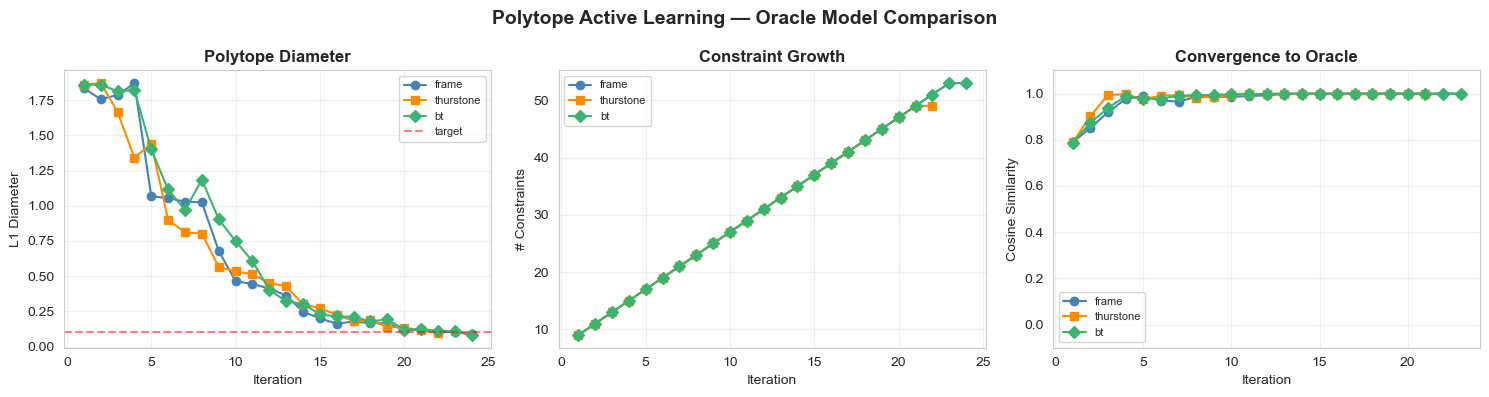

In [104]:
# Diagnostics: compare all oracle models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {'frame': 'steelblue', 'thurstone': 'darkorange', 'bt': 'mediumseagreen'}
markers = {'frame': 'o', 'thurstone': 's', 'bt': 'D'}

for name, res in results.items():
    hist = res['history']
    if len(hist) < 2:
        continue
    iters = [h['iteration'] for h in hist]
    diams = [h['diameter'] for h in hist]
    n_cons = [h['n_constraints'] for h in hist]
    cos_sims = [h.get('cosine_similarity', None) for h in hist]
    cos_sims_clean = [c for c in cos_sims if c is not None]

    m, c = markers[name], colors[name]
    axes[0].plot(iters, diams, f'{m}-', color=c, label=name)
    axes[1].plot(iters, n_cons, f'{m}-', color=c, label=name)
    if cos_sims_clean:
        axes[2].plot(range(1, len(cos_sims_clean) + 1), cos_sims_clean,
                     f'{m}-', color=c, label=name)

axes[0].axhline(0.1, color='red', linestyle='--', alpha=0.5, label='target')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('L1 Diameter')
axes[0].set_title('Polytope Diameter', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('# Constraints')
axes[1].set_title('Constraint Growth', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Cosine Similarity')
axes[2].set_title('Convergence to Oracle', fontweight='bold')
axes[2].set_ylim(-0.1, 1.1)
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle('Polytope Active Learning — Oracle Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

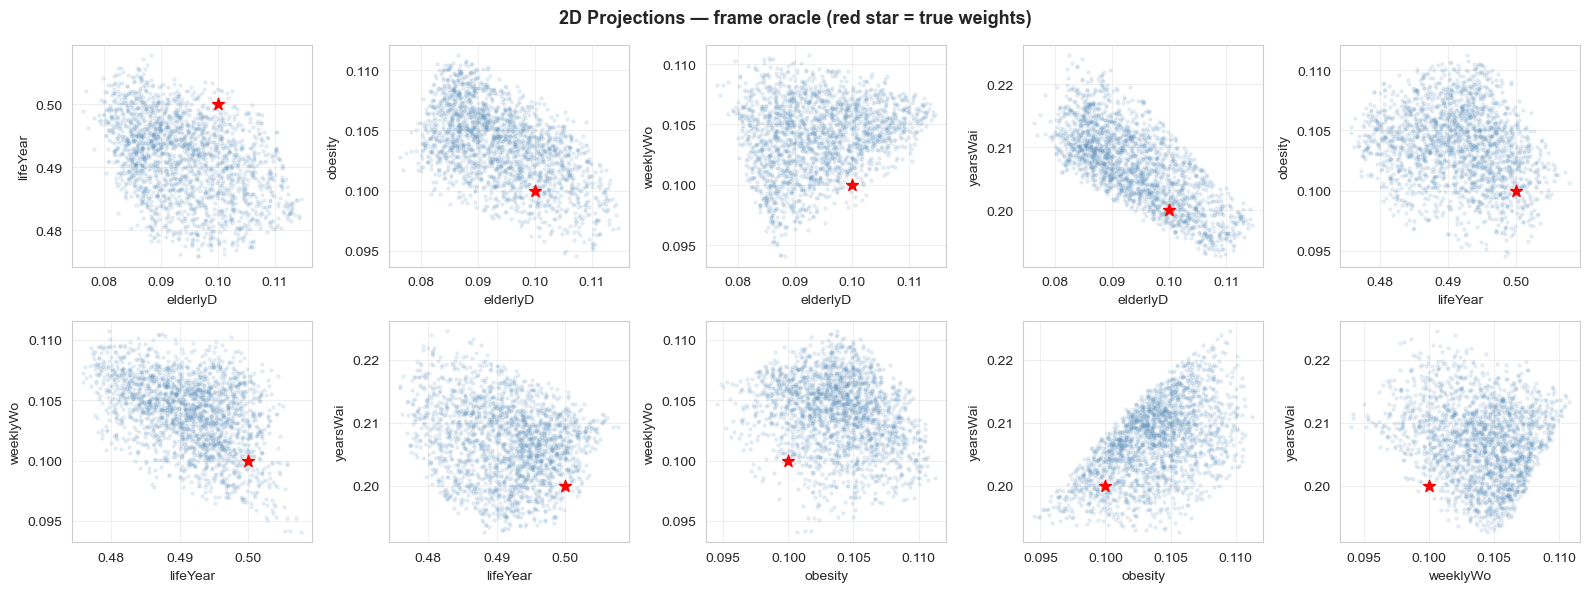

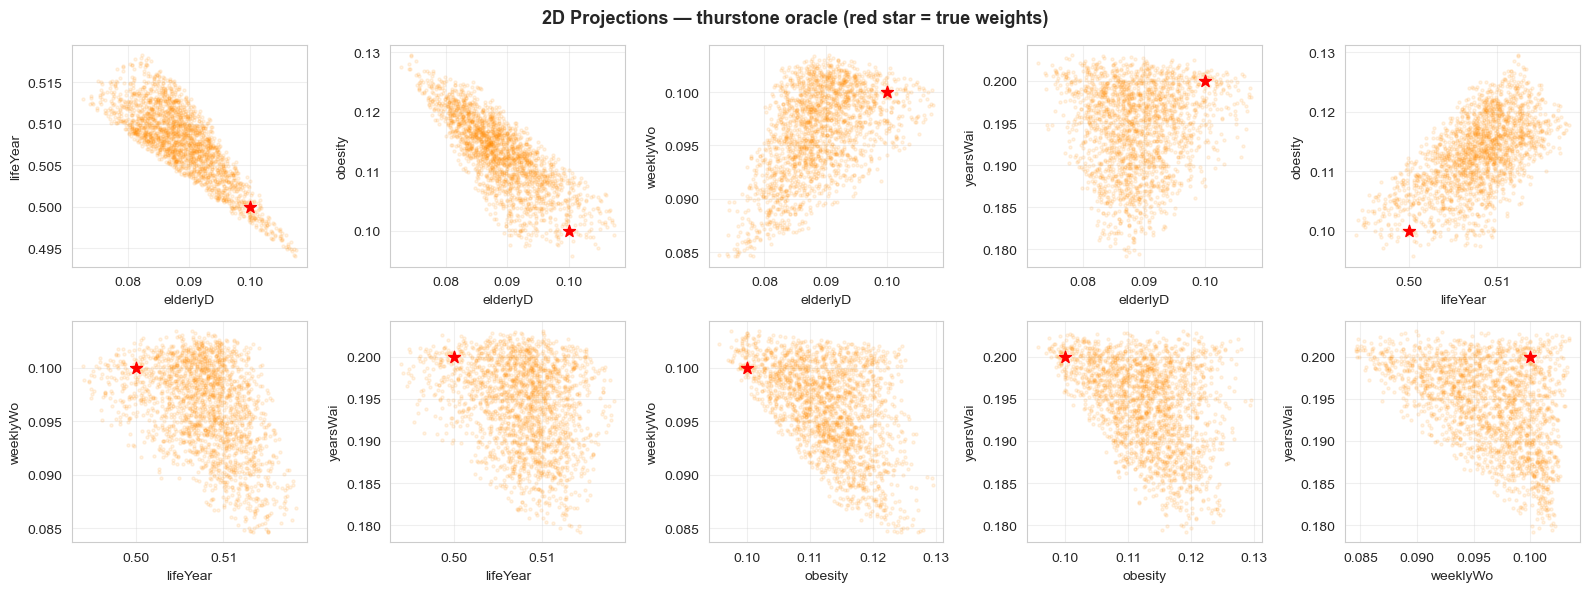

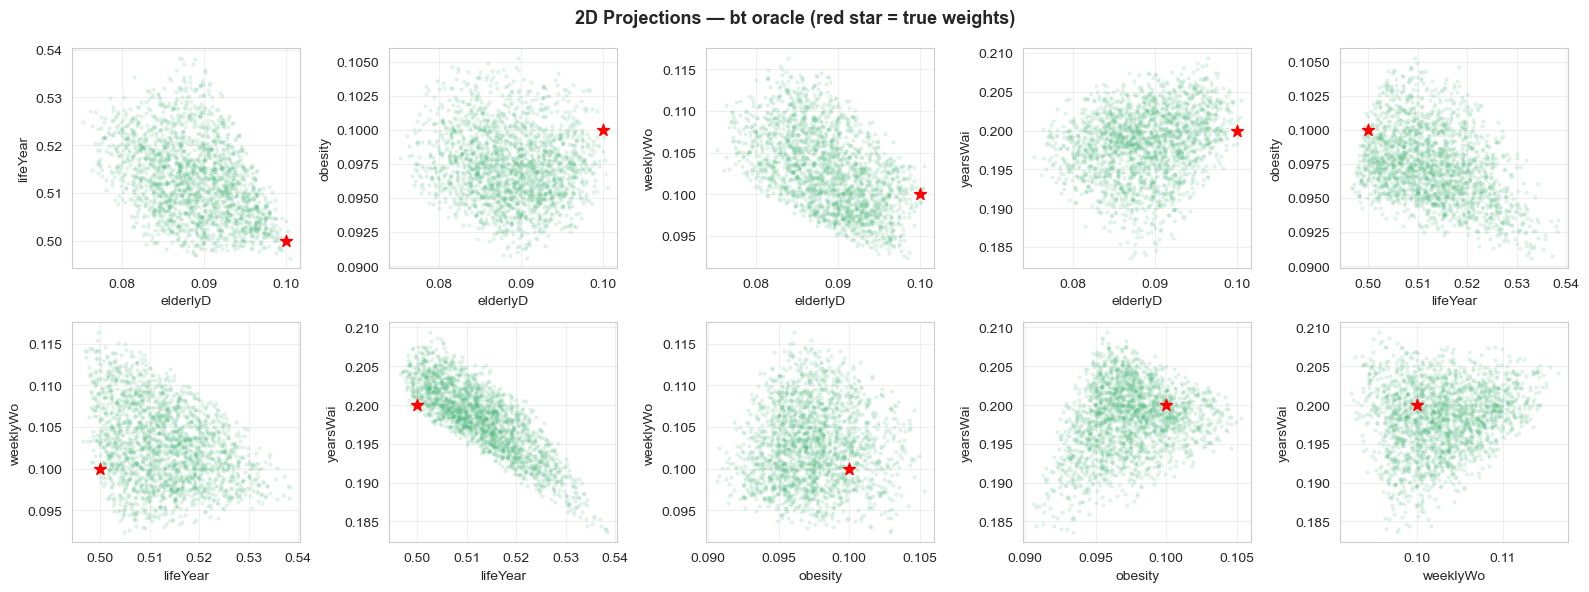

In [105]:
# 2D projections for all oracle models
from itertools import combinations

pairs = list(combinations(range(5), 2))

for name, res in results.items():
    try:
        samps = res['polytope'].sample(2000, burn_in=500, thin=5)
    except ValueError:
        print(f'{name}: Polytope is empty — cannot visualize.')
        continue

    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    for idx, (i, j) in enumerate(pairs):
        ax = axes[idx // 5, idx % 5]
        ax.scatter(samps[:, i], samps[:, j], alpha=0.1, s=5, color=colors[name])
        ax.scatter(oracle_w[i], oracle_w[j], color='red', s=80, zorder=5, marker='*')
        ax.set_xlabel(FEATURE_NAMES[i][:8])
        ax.set_ylabel(FEATURE_NAMES[j][:8])
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'2D Projections — {name} oracle (red star = true weights)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Monte Carlo Experiment

Run the polytope active learning across **10 random weight vectors × 3 oracle models × 20 trials** to get robust convergence statistics.

In [ ]:
# Generate 10 random weight vectors on the simplex
np.random.seed(0)
n_weights = 10
weight_vectors = np.random.dirichlet(np.ones(5), size=n_weights)

print('Weight vectors (simplex):')
for i, w in enumerate(weight_vectors):
    print(f'  w[{i}] = {np.array2string(w, precision=3)}')

In [ ]:
import time

models = {'frame': predict_frame, 'thurstone': predict_thurstone, 'bt': predict_bt}
n_trials = 20
max_iter = 30
target_diam = 0.1

# results_mc[w_idx][model_name] = list of n_trials history lists
results_mc = {}

t0 = time.time()
total = n_weights * len(models) * n_trials
done = 0

for w_idx, w_vec in enumerate(weight_vectors):
    results_mc[w_idx] = {}
    for model_name, model_fn in models.items():
        trials = []
        for trial in range(n_trials):
            np.random.seed(w_idx * 1000 + trial)
            _, hist = active_learning_polytope(
                max_iterations=max_iter,
                n_samples=1000,
                n_candidates=100,
                geometry='simplex',
                oracle_weights=w_vec,
                oracle_model=model_fn,
                target_diameter=target_diam,
                verbose=False,
            )
            trials.append(hist)
            done += 1

        results_mc[w_idx][model_name] = trials
        elapsed = time.time() - t0
        rate = done / elapsed if elapsed > 0 else 0
        remaining = (total - done) / rate if rate > 0 else 0
        print(f'  w[{w_idx}] {model_name:10s}: {n_trials} trials done  '
              f'[{done}/{total}, ~{remaining:.0f}s remaining]')

print(f'\nAll done in {time.time() - t0:.1f}s')

In [ ]:
# Aggregate: for each model, collect diameter and cosine_sim curves
# across all weight vectors and trials, padded to max_iter length.

def extract_curves(results_mc, max_iter):
    """Extract per-model arrays of shape (n_total_trials, max_iter)."""
    model_diameters = {m: [] for m in models}
    model_cossims = {m: [] for m in models}

    for w_idx in results_mc:
        for model_name in models:
            for hist in results_mc[w_idx][model_name]:
                diams = [h['diameter'] for h in hist]
                cossims = [h.get('cosine_similarity', np.nan) for h in hist]

                # Pad to max_iter by forward-filling last value
                while len(diams) < max_iter:
                    diams.append(diams[-1] if diams else np.nan)
                while len(cossims) < max_iter:
                    cossims.append(cossims[-1] if cossims else np.nan)

                model_diameters[model_name].append(diams[:max_iter])
                model_cossims[model_name].append(cossims[:max_iter])

    # Convert to arrays
    for m in models:
        model_diameters[m] = np.array(model_diameters[m])
        model_cossims[m] = np.array(model_cossims[m])

    return model_diameters, model_cossims


model_diameters, model_cossims = extract_curves(results_mc, max_iter)

for m in models:
    print(f'{m}: {model_diameters[m].shape[0]} trials, '
          f'final mean diam = {np.nanmean(model_diameters[m][:, -1]):.4f}')

In [ ]:
# Plot mean convergence curves with std bands
colors_mc = {'frame': 'steelblue', 'thurstone': 'darkorange', 'bt': 'mediumseagreen'}
iters = np.arange(1, max_iter + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Diameter ---
ax = axes[0]
for m in models:
    mean = np.nanmean(model_diameters[m], axis=0)
    std = np.nanstd(model_diameters[m], axis=0)
    ax.plot(iters, mean, '-', color=colors_mc[m], label=m, linewidth=2)
    ax.fill_between(iters, mean - std, mean + std, color=colors_mc[m], alpha=0.15)
ax.axhline(target_diam, color='red', linestyle='--', alpha=0.5, label='target')
ax.set_xlabel('Iteration')
ax.set_ylabel('L1 Diameter')
ax.set_title('Mean Polytope Diameter', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Cosine similarity ---
ax = axes[1]
for m in models:
    mean = np.nanmean(model_cossims[m], axis=0)
    std = np.nanstd(model_cossims[m], axis=0)
    ax.plot(iters, mean, '-', color=colors_mc[m], label=m, linewidth=2)
    ax.fill_between(iters, mean - std, mean + std, color=colors_mc[m], alpha=0.15)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cosine Similarity to Oracle')
ax.set_title('Mean Convergence to Oracle', fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(f'Polytope Active Learning — {n_weights} weight vectors × {n_trials} trials',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Iterations to converge (diameter < target) per model
fig, ax = plt.subplots(figsize=(8, 5))

convergence_iters = {m: [] for m in models}
for w_idx in results_mc:
    for m in models:
        for hist in results_mc[w_idx][m]:
            diams = [h['diameter'] for h in hist]
            converged_at = max_iter  # default: didn't converge
            for i, d in enumerate(diams):
                if d <= target_diam:
                    converged_at = i + 1
                    break
            convergence_iters[m].append(converged_at)

positions = np.arange(len(models))
means = [np.mean(convergence_iters[m]) for m in models]
stds = [np.std(convergence_iters[m]) for m in models]
model_names = list(models.keys())

bars = ax.bar(positions, means, yerr=stds, capsize=5,
              color=[colors_mc[m] for m in model_names], edgecolor='black', alpha=0.8)
ax.set_xticks(positions)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('Iterations to Converge')
ax.set_title(f'Mean Iterations to Convergence (diam < {target_diam})\n'
             f'{n_weights} weight vectors × {n_trials} trials',
             fontweight='bold')
ax.axhline(max_iter, color='red', linestyle='--', alpha=0.4, label=f'max ({max_iter})')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate bars
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.3,
            f'{mean:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print fraction that converged
for m in model_names:
    frac = np.mean(np.array(convergence_iters[m]) < max_iter)
    print(f'{m:10s}: converged {frac*100:.0f}% of trials, '
          f'mean iters = {np.mean(convergence_iters[m]):.1f} ± {np.std(convergence_iters[m]):.1f}')

In [ ]:
# Per-weight-vector convergence heatmap
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5))

for ax, m in zip(axes, models):
    # Shape: (n_weights, n_trials) of convergence iterations
    grid = np.zeros((n_weights, n_trials))
    for w_idx in range(n_weights):
        for t, hist in enumerate(results_mc[w_idx][m]):
            diams = [h['diameter'] for h in hist]
            converged_at = max_iter
            for i, d in enumerate(diams):
                if d <= target_diam:
                    converged_at = i + 1
                    break
            grid[w_idx, t] = converged_at

    im = ax.imshow(grid, aspect='auto', cmap='YlOrRd', vmin=1, vmax=max_iter)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Weight vector index')
    ax.set_title(f'{m}', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Iterations to converge')

fig.suptitle('Convergence Speed per Weight Vector and Trial', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# Grid Experiment: tau x tau_prime sweep
# ============================================================================
import time

taus = [0.0, 0.2, 0.4, 0.6, 0.8]
tau_primes = [0.0, 0.5, 1.0, 1.5, 2.0]
N_trials = 5
max_iter = 30
oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

grid_results = {}  # (tau, tau_prime) -> list of histories

total_cells = len(taus) * len(tau_primes)
cell_idx = 0
t0 = time.time()

for tau in taus:
    for tau_prime in tau_primes:
        cell_idx += 1
        print(f"Cell {cell_idx}/{total_cells}: tau={tau}, tau'={tau_prime} ", end="", flush=True)
        
        histories = []
        for trial in range(N_trials):
            oracle_fn = lambda q, w, _tau=tau, _tp=tau_prime: predict_frame(
                q, w, _tau, _tp, LAMBDA_X
            )
            _, hist = active_learning_polytope(
                max_iterations=max_iter,
                n_samples=500,
                n_candidates=50,
                tau=tau,
                tau_prime=tau_prime,
                oracle_weights=oracle_weights,
                oracle_model=oracle_fn,
                target_diameter=0.01,
                verbose=False,
            )
            histories.append(hist)
        
        grid_results[(tau, tau_prime)] = histories
        
        # Show mean final cosine sim
        final_cos = []
        for h in histories:
            cos_vals = [step.get('cosine_similarity', np.nan) for step in h if 'cosine_similarity' in step]
            if cos_vals:
                final_cos.append(cos_vals[-1])
        mean_cos = np.mean(final_cos) if final_cos else np.nan
        print(f"-> cos_sim={mean_cos:.3f} ({time.time()-t0:.0f}s)")

print(f"\nDone in {time.time()-t0:.1f}s")

In [ ]:
# ============================================================================
# Grid Plot 1: Cosine Similarity Convergence
# ============================================================================
import matplotlib
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

n_rows = len(tau_primes)
n_cols = len(taus)
figsize_per_cell = (1.2, 1.0)
fig_w = figsize_per_cell[0] * n_cols + 1.5
fig_h = figsize_per_cell[1] * n_rows + 1.2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), sharex=True, sharey=True)

for i, tp in enumerate(tau_primes):
    for j, tau in enumerate(taus):
        ax = axes[n_rows - 1 - i, j]
        histories = grid_results.get((tau, tp), [])

        all_curves = []
        for h in histories:
            curve = [step.get('cosine_similarity', np.nan) for step in h if 'cosine_similarity' in step]
            if curve:
                all_curves.append(curve)

        if all_curves:
            max_len = max(len(c) for c in all_curves)
            padded = [c + [c[-1]] * (max_len - len(c)) for c in all_curves]
            arr = np.array(padded)
            mean_curve = arr.mean(axis=0)
            stderr = arr.std(axis=0) / np.sqrt(len(arr))
            x = np.arange(1, len(mean_curve) + 1)

            ax.plot(x, mean_curve, '-', color='#4477AA', linewidth=1.2)
            ax.fill_between(x, mean_curve - stderr, mean_curve + stderr,
                           color='#4477AA', alpha=0.15)

        ax.set_ylim([0, 1.05])
        ax.set_xlim([1, max_iter])
        ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.3, linewidth=0.5)

        # Labels on edges only
        if j == 0:  # Left column
            ax.set_ylabel(f"τ'={tp}", fontsize=7)
        else:
            ax.tick_params(labelleft=False)

        if n_rows - 1 - i == 0:  # Top row
            ax.set_title(f"τ={tau}", fontsize=7)

        ax.tick_params(labelsize=5)

fig.suptitle('Polytope Volume Removal: Cosine Similarity', fontsize=10, y=0.95)
fig.text(0.5, 0.9, 'τ (indifference threshold)', ha='center', fontsize=9)
fig.text(0.02, 0.5, "τ' (incomparability threshold)", va='center',
        rotation='vertical', fontsize=9)
fig.text(0.5, 0.02, 'Iteration', ha='center', fontsize=9)

plt.tight_layout(rect=[0.03, 0.05, 1, 0.95])
plt.show()

In [ ]:
# ============================================================================
# Grid Plot 2: Polytope Diameter Convergence
# ============================================================================

n_rows = len(tau_primes)
n_cols = len(taus)
figsize_per_cell = (1.2, 1.0)
fig_w = figsize_per_cell[0] * n_cols + 1.5
fig_h = figsize_per_cell[1] * n_rows + 1.2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), sharex=True, sharey=True)

for i, tp in enumerate(tau_primes):
    for j, tau in enumerate(taus):
        ax = axes[n_rows - 1 - i, j]
        histories = grid_results.get((tau, tp), [])

        all_curves = []
        for h in histories:
            curve = [step['diameter'] for step in h]
            if curve:
                all_curves.append(curve)

        if all_curves:
            max_len = max(len(c) for c in all_curves)
            padded = [c + [c[-1]] * (max_len - len(c)) for c in all_curves]
            arr = np.array(padded)
            mean_curve = arr.mean(axis=0)
            stderr = arr.std(axis=0) / np.sqrt(len(arr))
            x = np.arange(1, len(mean_curve) + 1)

            ax.plot(x, mean_curve, '-', color='#EE6677', linewidth=1.2)
            ax.fill_between(x, mean_curve - stderr, mean_curve + stderr,
                           color='#EE6677', alpha=0.15)

        ax.set_xlim([1, max_iter])
        ax.axhline(y=0.0, color='gray', linestyle=':', alpha=0.3, linewidth=0.5)

        # Labels on edges only
        if j == 0:  # Left column
            ax.set_ylabel(f"τ'={tp}", fontsize=7)
        else:
            ax.tick_params(labelleft=False)

        if n_rows - 1 - i == 0:  # Top row
            ax.set_title(f"τ={tau}", fontsize=7)

        ax.tick_params(labelsize=5)

fig.suptitle('Polytope Volume Removal: L1 Diameter', fontsize=10, y=0.95)
fig.text(0.5, 0.9, 'τ (indifference threshold)', ha='center', fontsize=9)
fig.text(0.02, 0.5, "τ' (incomparability threshold)", va='center',
        rotation='vertical', fontsize=9)
fig.text(0.5, 0.02, 'Iteration', ha='center', fontsize=9)

plt.tight_layout(rect=[0.03, 0.05, 1, 0.95])
plt.show()